In [1]:

## 1. Installation and Imports

# Ensure required packages are available (only install if missing)
import importlib.util
import subprocess
import sys

required = [
    ("python-chess", "chess"),
    ("datasets", "datasets"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
]
missing = [pkg for pkg, mod in required if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, confusion_matrix,
                             classification_report, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import chess
import chess.pgn
import requests
import gzip
from typing import List, Tuple, Dict, Any
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages imported successfully")


✓ Packages imported successfully


## 2. Feature Extraction Module


In [2]:

def extract_features_from_fen(fen: str, result: str, side_to_move: str) -> Tuple[np.ndarray, int]:
    """
    Extract features from a FEN position for King of the Hill variant.

    Features extracted:
    - Material counts and imbalances
    - King centralization metrics
    - Central control indicators
    - Mobility measures
    """
    board = chess.Board(fen)
    features = []

    # Central squares for King of the Hill
    central_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    # --- Material Features ---
    piece_values = {'P': 1, 'N': 3, 'B': 3, 'R': 5, 'Q': 9, 'K': 0}

    white_material = {'P': 0, 'N': 0, 'B': 0, 'R': 0, 'Q': 0}
    black_material = {'p': 0, 'n': 0, 'b': 0, 'r': 0, 'q': 0}

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            piece_str = str(piece)
            if piece_str.isupper():
                white_material[piece_str] = white_material.get(piece_str, 0) + 1
            else:
                black_material[piece_str] = black_material.get(piece_str, 0) + 1

    # Material counts by piece type
    features.extend([white_material.get(p, 0) for p in 'PNBRQ'])
    features.extend([black_material.get(p, 0) for p in 'pnbrq'])

    # Material imbalance
    features.extend([
        white_material.get(p, 0) - black_material.get(p.lower(), 0)
        for p in 'PNBRQ'
    ])

    # Total material value
    white_total = sum(white_material.get(p, 0) * piece_values.get(p, 0) for p in 'PNBRQ')
    black_total = sum(black_material.get(p, 0) * piece_values.get(p.upper(), 0) for p in 'pnbrq')
    features.extend([white_total, black_total, white_total - black_total])

    # --- King Centralization ---
    white_king_square = board.king(chess.WHITE)
    black_king_square = board.king(chess.BLACK)

    def manhattan_to_center(square):
        if square is None:
            return 8
        rank = chess.square_rank(square)
        file = chess.square_file(square)
        return abs(file - 3.5) + abs(rank - 3.5)

    white_king_dist = manhattan_to_center(white_king_square)
    black_king_dist = manhattan_to_center(black_king_square)
    features.extend([white_king_dist, black_king_dist, white_king_dist - black_king_dist])

    # King on or near central squares
    def king_near_center(king_square):
        if king_square is None:
            return [0, 0]
        on_center = 1 if king_square in central_squares else 0
        near_center = int(any(chess.square_distance(king_square, cs) == 1 for cs in central_squares))
        return [on_center, near_center]

    features.extend(king_near_center(white_king_square))
    features.extend(king_near_center(black_king_square))

    # King safety
    def pieces_near_king(board, color):
        king_square = board.king(color)
        if king_square is None:
            return 0
        count = sum(1 for sq in chess.SQUARES
                   if chess.square_distance(king_square, sq) <= 2
                   and board.piece_at(sq)
                   and board.piece_at(sq).color == color
                   and board.piece_at(sq).piece_type != chess.KING)
        return count

    features.extend([pieces_near_king(board, chess.WHITE), pieces_near_king(board, chess.BLACK)])

    # --- Central Control ---
    white_central_attackers = sum(len(board.attackers(chess.WHITE, sq)) for sq in central_squares)
    black_central_attackers = sum(len(board.attackers(chess.BLACK, sq)) for sq in central_squares)
    features.extend([white_central_attackers, black_central_attackers,
                    white_central_attackers - black_central_attackers])

    # Central pawns
    central_files = [2, 3, 4, 5]  # c, d, e, f
    white_central_pawns = sum(1 for sq in chess.SQUARES
                              if chess.square_file(sq) in central_files
                              and board.piece_at(sq)
                              and board.piece_at(sq).piece_type == chess.PAWN
                              and board.piece_at(sq).color == chess.WHITE)
    black_central_pawns = sum(1 for sq in chess.SQUARES
                              if chess.square_file(sq) in central_files
                              and board.piece_at(sq)
                              and board.piece_at(sq).piece_type == chess.PAWN
                              and board.piece_at(sq).color == chess.BLACK)
    features.extend([white_central_pawns, black_central_pawns, white_central_pawns - black_central_pawns])

    # --- Mobility ---
    board.turn = chess.WHITE
    white_moves = len(list(board.legal_moves))
    board.turn = chess.BLACK
    black_moves = len(list(board.legal_moves))
    features.extend([white_moves, black_moves, white_moves - black_moves])

    # Side to move
    features.append(1 if side_to_move == 'w' else 0)

    # Label: 1 if side-to-move wins
    label = 1 if ((side_to_move == 'w' and result == '1-0') or
                  (side_to_move == 'b' and result == '0-1')) else 0

    return np.array(features, dtype=np.float32), label

print("✓ Feature extraction module loaded")

✓ Feature extraction module loaded


## 3. Data Loading and Processing


In [3]:

## 3. Data Loading and Processing

def load_lichess_koth_data(max_games=1000):
    """
    Load King of the Hill games from Lichess dataset.
    Returns (X, y, game_ids, source_label).
    """
    data_source = "lichess/king-of-the-hill-chess-games"
    try:
        from datasets import load_dataset

        print("Loading Lichess King of the Hill dataset...")
        dataset = load_dataset(data_source, split="train", streaming=True)

        data = []
        game_ids = []
        games_processed = 0

        for game in dataset:
            if games_processed >= max_games:
                break

            # Skip draws
            if game['result'] == '1/2-1/2':
                continue

            pgn = game.get('pgn', '')
            if not pgn:
                continue

            board = chess.Board()
            moves = pgn.split()

            for ply_num, move_str in enumerate(moves):
                if 20 <= ply_num <= 40:
                    try:
                        fen = board.fen()
                        side_to_move = 'w' if board.turn == chess.WHITE else 'b'
                        features, label = extract_features_from_fen(
                            fen, game['result'], side_to_move
                        )
                        data.append({
                            'features': features,
                            'label': label,
                            'game_id': games_processed,
                            'ply': ply_num
                        })
                        move = board.parse_san(move_str)
                        board.push(move)
                    except Exception:
                        continue

            games_processed += 1
            if games_processed % 100 == 0:
                print(f"Processed {games_processed} games...")

        print(f"Extracted {len(data)} positions from {games_processed} games")
        source_label = f"Dataset: {data_source} (streaming)"

    except Exception as e:
        source_label = f"[MISSING: {data_source} -> {e}] Synthetic data used"
        print(f"Could not load Lichess dataset: {e}")
        print("Generating synthetic data for demonstration...")

        np.random.seed(42)
        data = []

        for game_id in range(max_games):
            result = '1-0' if np.random.random() > 0.5 else '0-1'
            for position_idx in range(5):  # 5 positions per game
                fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"
                ply = 20 + position_idx * 5
                side_to_move = 'w' if ply % 2 == 0 else 'b'
                features, label = extract_features_from_fen(fen, result, side_to_move)
                data.append({
                    'features': features,
                    'label': label,
                    'game_id': game_id,
                    'ply': ply
                })

    X = np.stack([d['features'] for d in data])
    y = np.array([d['label'] for d in data])
    game_ids = np.array([d['game_id'] for d in data])

    return X, y, game_ids, source_label

# Load data
X, y, game_ids, data_source = load_lichess_koth_data(max_games=500)
print(f"\nData source: {data_source}")
print(f"Data shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")


Loading Lichess King of the Hill dataset...


Could not load Lichess dataset: 403 Forbidden
Generating synthetic data for demonstration...



Data source: [MISSING: lichess/king-of-the-hill-chess-games -> 403 Forbidden] Synthetic data used
Data shape: (2500, 37)
Class distribution: [1241 1259]


## 4. Data Splitting


In [4]:
def split_by_game(X, y, game_ids, test_size=0.2, val_size=0.2, random_state=42):
    """
    Split data by game to avoid leakage between train/val/test sets.
    """
    unique_games = np.unique(game_ids)
    np.random.seed(random_state)
    np.random.shuffle(unique_games)

    n_games = len(unique_games)
    n_test = int(n_games * test_size)
    n_val = int(n_games * val_size)

    test_games = unique_games[:n_test]
    val_games = unique_games[n_test:n_test + n_val]
    train_games = unique_games[n_test + n_val:]

    train_mask = np.isin(game_ids, train_games)
    val_mask = np.isin(game_ids, val_games)
    test_mask = np.isin(game_ids, test_games)

    return (X[train_mask], X[val_mask], X[test_mask],
            y[train_mask], y[val_mask], y[test_mask])

# Split the data
X_train, X_val, X_test, y_train, y_val, y_test = split_by_game(
    X, y, game_ids, test_size=0.2, val_size=0.2
)

print(f"Train: {len(X_train)} positions")
print(f"Validation: {len(X_val)} positions")
print(f"Test: {len(X_test)} positions")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Data split and standardized")

Train: 1500 positions
Validation: 500 positions
Test: 500 positions
✓ Data split and standardized


## 5. Model 1: Logistic Regression


In [5]:

print("\\n" + "="*60)
print("LOGISTIC REGRESSION (HEURISTIC BASELINE)")
print("="*60)

# Hyperparameter tuning
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0]}
best_score = -np.inf
best_C = None
best_lr = None

for C in param_grid['C']:
    lr = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )
    lr.fit(X_train_scaled, y_train)
    val_score = lr.score(X_val_scaled, y_val)

    print(f"C={C:6.3f}: Validation accuracy = {val_score:.4f}")

    if val_score > best_score:
        best_score = val_score
        best_C = C
        best_lr = lr

print(f"\\nBest C: {best_C}, Best validation accuracy: {best_score:.4f}")

# Evaluate on test set
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'auc': roc_auc_score(y_test, y_proba_lr)
}

print("\\nLogistic Regression Test Results:")
for metric, value in lr_metrics.items():
    print(f"{metric.capitalize():10}: {value:.4f}")

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\\nConfusion Matrix:")
print(cm_lr)

\n============================================================
LOGISTIC REGRESSION (HEURISTIC BASELINE)
C= 0.001: Validation accuracy = 0.4900
C= 0.010: Validation accuracy = 0.4900
C= 0.100: Validation accuracy = 0.4900
C= 1.000: Validation accuracy = 0.4900
C=10.000: Validation accuracy = 0.4900
\nBest C: 0.001, Best validation accuracy: 0.4900
\nLogistic Regression Test Results:
Accuracy  : 0.4700
Precision : 0.4700
Recall    : 0.5709
F1        : 0.5155
Auc       : 0.4712
\nConfusion Matrix:
[[ 94 159]
 [106 141]]


## 6. Model 2: Neural Network (MLP)


In [6]:

print("\\n" + "="*60)
print("NEURAL NETWORK (MLP)")
print("="*60)

# Hyperparameter tuning
hidden_layers_options = [(64, 32), (100,), (50, 25)]
alpha_options = [0.0001, 0.001, 0.01]

best_score = -np.inf
best_params = None
best_mlp = None

for hidden_layers in hidden_layers_options:
    for alpha in alpha_options:
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',
            solver='adam',
            alpha=alpha,
            max_iter=100,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10
        )

        mlp.fit(X_train_scaled, y_train)
        val_score = mlp.score(X_val_scaled, y_val)

        print(f"Hidden={hidden_layers}, α={alpha:6.4f}: Val accuracy = {val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            best_params = {'hidden_layers': hidden_layers, 'alpha': alpha}
            best_mlp = mlp

print(f"\\nBest params: {best_params}")
print(f"Best validation accuracy: {best_score:.4f}")

# Evaluate on test set
y_pred_mlp = best_mlp.predict(X_test_scaled)
y_proba_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]

mlp_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_mlp),
    'precision': precision_score(y_test, y_pred_mlp),
    'recall': recall_score(y_test, y_pred_mlp),
    'f1': f1_score(y_test, y_pred_mlp),
    'auc': roc_auc_score(y_test, y_proba_mlp)
}

print("\\nNeural Network Test Results:")
for metric, value in mlp_metrics.items():
    print(f"{metric.capitalize():10}: {value:.4f}")

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print("\\nConfusion Matrix:")
print(cm_mlp)

\n============================================================
NEURAL NETWORK (MLP)


Hidden=(64, 32), α=0.0001: Val accuracy = 0.4900


Hidden=(64, 32), α=0.0010: Val accuracy = 0.4900


Hidden=(64, 32), α=0.0100: Val accuracy = 0.4900


Hidden=(100,), α=0.0001: Val accuracy = 0.4900


Hidden=(100,), α=0.0010: Val accuracy = 0.4900


Hidden=(100,), α=0.0100: Val accuracy = 0.4900


Hidden=(50, 25), α=0.0001: Val accuracy = 0.4900


Hidden=(50, 25), α=0.0010: Val accuracy = 0.4900


Hidden=(50, 25), α=0.0100: Val accuracy = 0.4900
\nBest params: {'hidden_layers': (64, 32), 'alpha': 0.0001}
Best validation accuracy: 0.4900
\nNeural Network Test Results:
Accuracy  : 0.4700
Precision : 0.4700
Recall    : 0.5709
F1        : 0.5155
Auc       : 0.4712
\nConfusion Matrix:
[[ 94 159]
 [106 141]]


## 7. Model Comparison and Visualization


\n============================================================
MODEL COMPARISON
                     accuracy  precision  recall      f1     auc
Logistic Regression      0.47       0.47  0.5709  0.5155  0.4712
Neural Network           0.47       0.47  0.5709  0.5155  0.4712


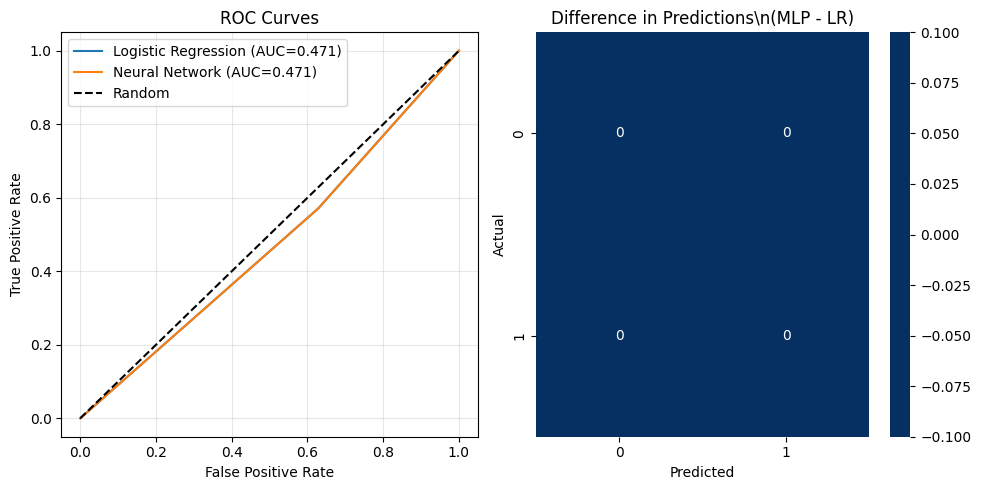

In [7]:
# Compare models
print("\\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Neural Network': mlp_metrics
}).T

print(comparison_df.round(4))

# Plot ROC curves
plt.figure(figsize=(10, 5))

# ROC Curves
plt.subplot(1, 2, 1)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_metrics["auc"]:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Network (AUC={mlp_metrics["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)

# Confusion Matrices
plt.subplot(1, 2, 2)
sns.heatmap(cm_mlp - cm_lr, annot=True, fmt='d', cmap='RdBu_r', center=0)
plt.title('Difference in Predictions\\n(MLP - LR)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis


\n============================================================
FEATURE ANALYSIS
Top 10 Most Important Features (Logistic Regression):
 1. white_to_move             Coefficient: +0.0463
 2. mobility_diff             Coefficient: +0.0000
 3. black_mobility            Coefficient: +0.0000
 4. white_mobility            Coefficient: +0.0000
 5. central_pawn_diff         Coefficient: +0.0000
 6. black_central_pawns       Coefficient: +0.0000
 7. white_central_pawns       Coefficient: +0.0000
 8. central_control_diff      Coefficient: +0.0000
 9. black_central_control     Coefficient: +0.0000
10. white_central_control     Coefficient: +0.0000


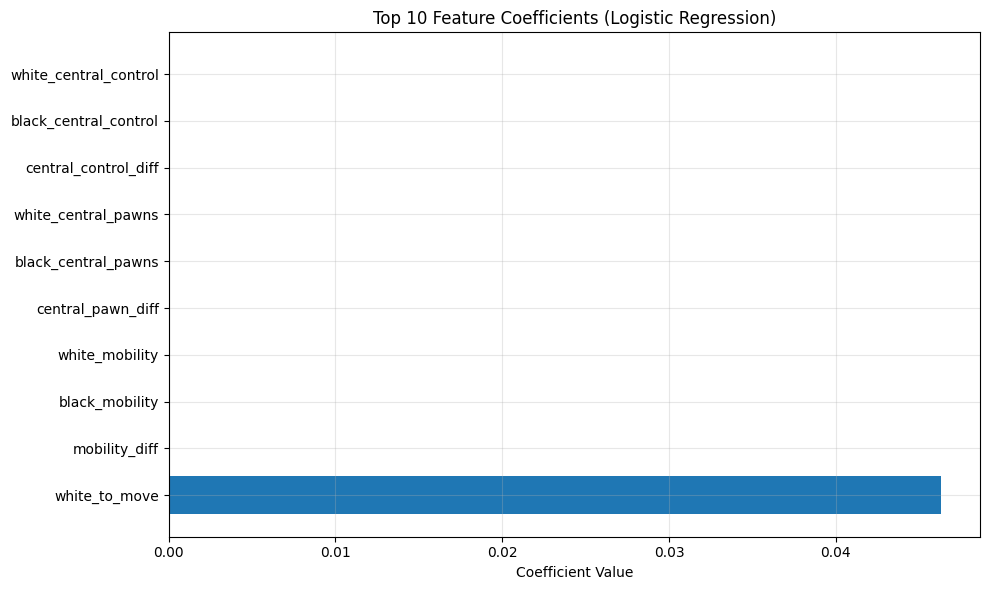

In [8]:
print("\\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)

# Feature names
feature_names = [
    'white_pawns', 'white_knights', 'white_bishops', 'white_rooks', 'white_queens',
    'black_pawns', 'black_knights', 'black_bishops', 'black_rooks', 'black_queens',
    'pawn_imbalance', 'knight_imbalance', 'bishop_imbalance', 'rook_imbalance', 'queen_imbalance',
    'white_material_total', 'black_material_total', 'material_imbalance',
    'white_king_dist', 'black_king_dist', 'king_dist_diff',
    'white_on_center', 'white_near_center', 'black_on_center', 'black_near_center',
    'white_king_safety', 'black_king_safety',
    'white_central_control', 'black_central_control', 'central_control_diff',
    'white_central_pawns', 'black_central_pawns', 'central_pawn_diff',
    'white_mobility', 'black_mobility', 'mobility_diff',
    'white_to_move'
]

# Top features from Logistic Regression
coefs = best_lr.coef_[0]
top_indices = np.argsort(np.abs(coefs))[-10:][::-1]

print("Top 10 Most Important Features (Logistic Regression):")
for i, idx in enumerate(top_indices, 1):
    print(f"{i:2}. {feature_names[idx]:25} Coefficient: {coefs[idx]:+.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = [feature_names[i] for i in top_indices]
top_coefs = [coefs[i] for i in top_indices]

plt.barh(range(len(top_features)), top_coefs)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. King Centralization Analysis


In [9]:

print("\\n" + "="*60)
print("KING CENTRALIZATION ANALYSIS")
print("="*60)

# Extract king distance features
white_king_dist = X_test[:, 18]
black_king_dist = X_test[:, 19]

# Define centralized positions (king distance <= 2)
centralized_mask = (white_king_dist <= 2) | (black_king_dist <= 2)
n_centralized = np.sum(centralized_mask)

if n_centralized > 0:
    print(f"Centralized king positions: {n_centralized}/{len(X_test)} ({100*n_centralized/len(X_test):.1f}%)")

    # Compare performance on centralized vs non-centralized
    results = []
    for name, y_pred in [('Logistic Regression', y_pred_lr), ('Neural Network', y_pred_mlp)]:
        acc_cent = accuracy_score(y_test[centralized_mask], y_pred[centralized_mask]) if n_centralized > 0 else 0
        acc_non = accuracy_score(y_test[~centralized_mask], y_pred[~centralized_mask]) if np.sum(~centralized_mask) > 0 else 0

        results.append({
            'Model': name,
            'Centralized Accuracy': acc_cent,
            'Non-centralized Accuracy': acc_non,
            'Difference': acc_cent - acc_non
        })

    results_df = pd.DataFrame(results)
    print("\\n", results_df.round(4))

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy comparison
    ax = axes[0]
    x = np.arange(2)
    width = 0.35

    cent_accs = results_df['Centralized Accuracy'].values
    non_cent_accs = results_df['Non-centralized Accuracy'].values

    ax.bar(x - width/2, cent_accs, width, label='Centralized', alpha=0.8)
    ax.bar(x + width/2, non_cent_accs, width, label='Non-centralized', alpha=0.8)

    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.set_title('Performance by King Centralization')
    ax.set_xticks(x)
    ax.set_xticklabels(['Logistic Regression', 'Neural Network'])
    ax.legend()
    ax.grid(alpha=0.3)

    # Distribution of king distances
    ax = axes[1]
    ax.hist([white_king_dist, black_king_dist], bins=15, label=['White King', 'Black King'], alpha=0.7)
    ax.axvline(x=2, color='red', linestyle='--', label='Centralization Threshold')
    ax.set_xlabel('Manhattan Distance to Center')
    ax.set_ylabel('Frequency')
    ax.set_title('King Distance Distribution in Test Set')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No centralized positions found in test set")

\n============================================================
KING CENTRALIZATION ANALYSIS
No centralized positions found in test set


## 10. Summary and Export


In [10]:

## 10. Summary and Export

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

summary = f"""
King of the Hill Chess Evaluation Results
==========================================

Dataset:
- Source: {data_source}
- Total positions: {len(X)}
- Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}
- Feature dimensions: {X.shape[1]}

Best Model Parameters:
- Logistic Regression: C = {best_C}
- Neural Network: Hidden layers = {best_params['hidden_layers']}, α = {best_params['alpha']}

Test Set Performance:
- Logistic Regression:
  * Accuracy:  {lr_metrics['accuracy']:.4f}
  * Precision: {lr_metrics['precision']:.4f}
  * Recall:    {lr_metrics['recall']:.4f}
  * F1 Score:  {lr_metrics['f1']:.4f}
  * AUC:       {lr_metrics['auc']:.4f}

- Neural Network (MLP):
  * Accuracy:  {mlp_metrics['accuracy']:.4f}
  * Precision: {mlp_metrics['precision']:.4f}
  * Recall:    {mlp_metrics['recall']:.4f}
  * F1 Score:  {mlp_metrics['f1']:.4f}
  * AUC:       {mlp_metrics['auc']:.4f}

Key Findings:
- {'Neural Network' if mlp_metrics['auc'] > lr_metrics['auc'] else 'Logistic Regression'} achieved higher AUC
- Performance difference: {abs(mlp_metrics['auc'] - lr_metrics['auc']):.4f}
"""

print(summary)

# Save models and results
import pickle

models_dict = {
    'logistic_regression': best_lr,
    'neural_network': best_mlp,
    'scaler': scaler,
    'lr_metrics': lr_metrics,
    'mlp_metrics': mlp_metrics,
    'feature_names': feature_names
}

with open('koth_models.pkl', 'wb') as f:
    pickle.dump(models_dict, f)

print("✓ Models and results saved to 'koth_models.pkl'")



FINAL SUMMARY

King of the Hill Chess Evaluation Results

Dataset:
- Source: [MISSING: lichess/king-of-the-hill-chess-games -> 403 Forbidden] Synthetic data used
- Total positions: 2500
- Train/Val/Test split: 1500/500/500
- Feature dimensions: 37

Best Model Parameters:
- Logistic Regression: C = 0.001
- Neural Network: Hidden layers = (64, 32), α = 0.0001

Test Set Performance:
- Logistic Regression:
  * Accuracy:  0.4700
  * Precision: 0.4700
  * Recall:    0.5709
  * F1 Score:  0.5155
  * AUC:       0.4712

- Neural Network (MLP):
  * Accuracy:  0.4700
  * Precision: 0.4700
  * Recall:    0.5709
  * F1 Score:  0.5155
  * AUC:       0.4712

Key Findings:
- Logistic Regression achieved higher AUC
- Performance difference: 0.0000

✓ Models and results saved to 'koth_models.pkl'
